# TikTok Brand Analytics — Executive Business Report
## Nike vs. Adidas · From Attention to Audience Response

### The stakeholder question
**What kinds of TikTok content earn attention, how commercial are those messages, who carries them, how does the audience respond, and can we prioritize before publishing?**

This report condenses the analysis in `01`–`05` into a short decision story. Every number here comes from those notebooks; the detailed notebooks remain the evidence trail.

### Storyline
**1. Earn attention → 2. Carry commercial intent → 3. Choose the messenger → 4. Read the response → 5. Prioritize → Decide what to test**

> **Scope.** 4,457 search-visible public Nike and Adidas TikTok videos (Adidas 2,140 · Nike 2,317), official accounts and creator content. Search results are algorithmically ranked, so findings describe this collected sample, not TikTok as a whole. All findings are descriptive or predictive associations, not causal effects.
>
> **Metrics.** **WER** = weighted engagement rate. **BRI** = a video's WER ÷ its brand's median WER (1.0 = typical for that brand), so Nike and Adidas are each compared with their own baseline.

---
# Executive Summary

| Business question | What the analysis says | Key number | Decision implication |
|---|---|---|---|
| **1 · What earns attention?** | The brands' strongest content territories differ. Adidas over-indexes on Vibe / OOTD and Collaboration; Nike on Collaboration and Tutorial / Utility. Product Promo sits below baseline for both. | Adidas Vibe / OOTD **+21%** · Nike Tutorial **+11%** vs own baseline | Optimize against each brand's own baseline rather than copy one “winning format.” |
| **2 · Does stronger selling create stronger content?** | Explicit commerce cues are rare, and videos that carry one show no consistent engagement premium or penalty. | **96.5%** of videos carry no commerce cue | Treat commerce as a selective creative layer, not a default recipe. |
| **3 · Who should carry the message?** | Official accounts reach more people; creator (UGC) content engages more relative to the brand. No UGC tier is strongest across content types. | Median views **130k vs 99k** · median BRI **0.80 vs 1.09** (official vs UGC) | Match creator to content strategy instead of optimizing follower count. |
| **4 · How does the audience respond?** | Adidas comments are warmer overall, but the lead is topic-specific: Adidas leads on Fit & Comfort, Nike on Availability; purchase intent is level. | Fit & Comfort net **+24.7 vs +13.9** · Availability **+10.1 vs +22.6** (Adidas vs Nike) | Diagnose at topic level instead of declaring a sentiment “winner.” |
| **5 · Can we prioritize before publishing?** | A pre-publish screening model makes a shortlist richer in top-decile videos. It ranks; it does not forecast individual results. | Model's top 10% holds **2.39×** the top performers of a random pick | Use as a shortlist aid ahead of human review. |

### Executive conclusion
The strongest signal is **fit**: content territory, commercial intent, creator choice and audience response need to be read together. The analysis supports a **test-and-learn content strategy**, not a universal viral formula.

In [1]:
# Setup: loads the grouped aggregates built by scripts/build_executive_data.py from the same
# functions 02 / 04b / 04c / 04d use. No video-level or account-level data is needed here.
from pathlib import Path
import io
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from tiktok_brand.analysis.plots import (
    content_type_sentiment_dumbbell,
    relative_uplift_diverging,
    scale_content_bri_heatmap,
    topic_sentiment_gap_dumbbell,
)
from tiktok_brand.analysis.present import BRAND_COLORS, PLOT_RC

DATA = ROOT / "notebooks" / "executive_data"
SUMMARY = json.loads((DATA / "summary.json").read_text())
INK, MUTED = "#1a1a1a", "#888888"


def dedupe_labels(fig, min_gap=1.5):
    # Two brands with near-identical values get identical, overlapping value labels.
    for ax in fig.axes:
        seen = []
        for t in list(ax.texts):
            x, y = t.get_position()
            if any(s.get_text() == t.get_text() and abs(sx - x) < min_gap and abs(sy - y) < 0.3
                   for s, (sx, sy) in seen):
                t.remove()
            else:
                seen.append((t, (x, y)))
    return fig


def show(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    plt.close(fig)
    display(Image(buf.getvalue()))


print(
    f"videos={SUMMARY['videos']:,}  content-labeled={SUMMARY['content_labeled']:,}  "
    f"comments={SUMMARY['comments']:,} on {SUMMARY['comment_videos']} videos"
)

videos=4,457  content-labeled=887  comments=10,406 on 105 videos


---
# 1 · EARN ATTENTION
## The brands do not win in the same content territory

### Business question
**Which content directions earn above-baseline engagement for each brand — not just which are most common?**

- Positioning differs (brand-style labels, `02`): **Adidas** leans **Lifestyle / Styling / OOTD**; **Nike** leans **Technical / Performance**.
- Baselines differ: Adidas median WER **0.70%**, Nike **0.59%**. Each bar below compares a content type with its own brand's median.

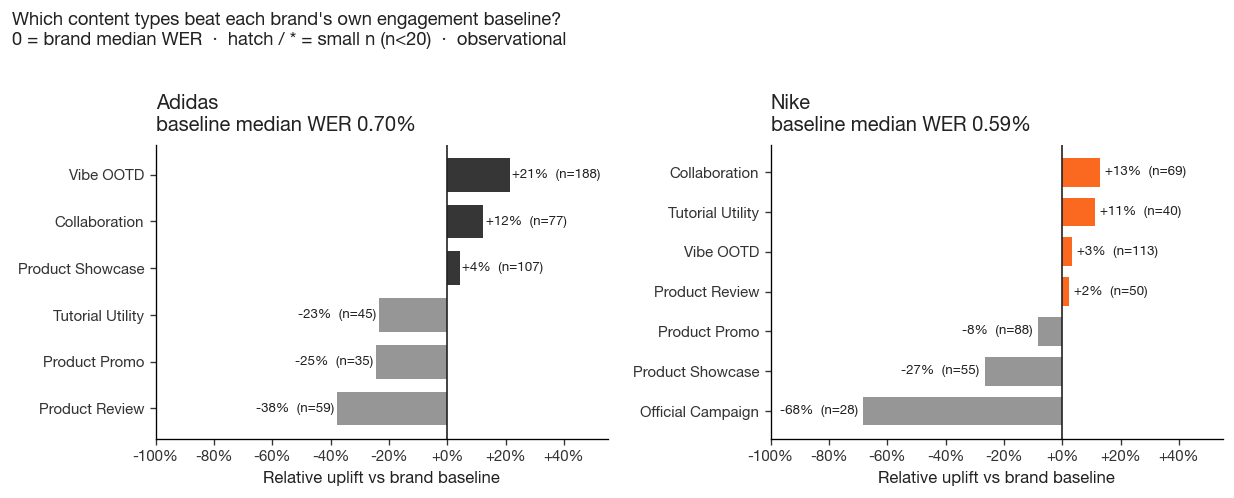

In [2]:
content = pd.read_csv(DATA / "content_type_relative.csv")
fig = relative_uplift_diverging(
    content,
    title="Which content types beat each brand's own engagement baseline?",
    reliable_only=True,
)
for ax in fig.axes:
    ax.set_xlim(-1.0, 0.55)
show(fig)

**Takeaway:** Adidas's strongest territories are Vibe / OOTD (+21%) and Collaboration (+12%); Nike's are Collaboration (+13%) and Tutorial / Utility (+11%). Product Promo sits below baseline for both, and Product Review splits: −38% for Adidas, +2% for Nike.

<small>**Scope:** videos with a content-type label (Adidas 471 · Nike 416); a video with several labels counts in each. Types with fewer than 20 videos for a brand are omitted. Median WER relative to the brand's median WER (equivalent to median BRI − 1); observational.<br>
**Label coverage:** content labels are rule-based and exist only where the taxonomy identifies a recognizable label (887 of 4,457 videos, 19.9%), so denominators differ by category.</small>

### The decision
**Do not ask “what format wins TikTok?” Ask “what content territory earns above-baseline engagement for this brand?”**

---
# 2 · CARRY COMMERCIAL INTENT
## High-performing TikTok is not simply “more promotional”

### Business question
**How much explicit commerce appears in the content — and does more selling correspond to stronger engagement?**

- **Commerce intensity** = purchase CTA + discovery / traffic CTA + promo language + giveaway (0–4 cues), binned None / Low / Medium / High.
- Nike is more commerce-oriented in this sample: mean intensity **0.050 vs 0.022**; Low share **4.7% vs 2.1%** (Nike vs Adidas).

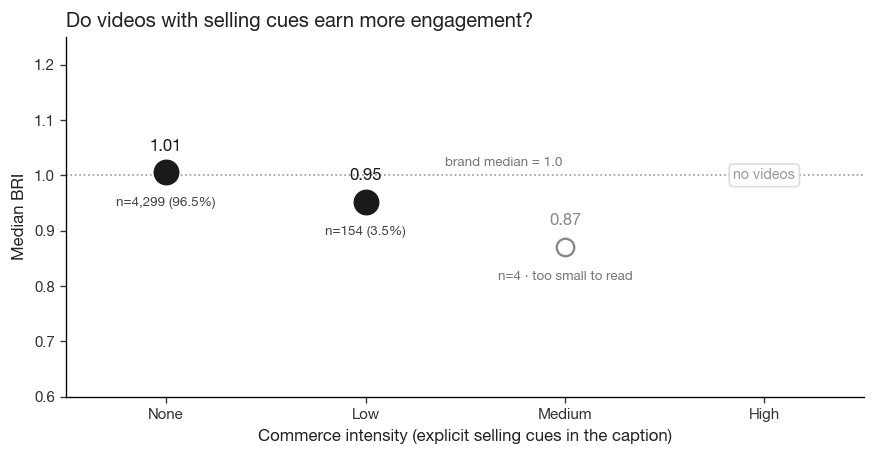

In [3]:
commerce = pd.read_csv(DATA / "commerce_trend.csv", keep_default_na=False, na_values=[""])
total = commerce["n"].sum()
plt.rcParams.update(PLOT_RC)
fig, ax = plt.subplots(figsize=(7.4, 3.9))
ax.axhline(1.0, color="#999", ls=":", lw=1)
ax.text(1.4, 1.012, "brand median = 1.0", va="bottom", ha="left", fontsize=8, color="#777")
for x, row in enumerate(commerce.itertuples()):
    if row.n == 0:
        ax.text(x, 1.0, "no videos", ha="center", va="center", fontsize=8.5, color="#999",
                bbox=dict(facecolor="white", edgecolor="#ddd", boxstyle="round,pad=0.3"))
        continue
    small = row.n < 20
    ax.scatter([x], [row.median_bri], s=200 if not small else 110, zorder=3,
               facecolor="white" if small else INK, edgecolor=MUTED if small else INK, linewidth=1.4)
    note = f"n={row.n:,}" + (f" ({row.n / total:.1%})" if not small else " · too small to read")
    ax.annotate(f"{row.median_bri:.2f}", (x, row.median_bri), xytext=(0, 13), textcoords="offset points",
                ha="center", fontsize=10, fontweight="bold", color=MUTED if small else INK)
    ax.annotate(note, (x, row.median_bri), xytext=(0, -20), textcoords="offset points",
                ha="center", fontsize=8, color="#777" if small else "#444")
ax.set_xticks(range(len(commerce)))
ax.set_xticklabels(commerce["commerce_intensity"])
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(0.6, 1.25)
ax.set_xlabel("Commerce intensity (explicit selling cues in the caption)")
ax.set_ylabel("Median BRI")
ax.set_title("Do videos with selling cues earn more engagement?", loc="left")
fig.tight_layout()
show(fig)

**Takeaway:** Videos with a Low commerce cue sit close to no-cue videos on median BRI (0.95 vs 1.01) and have a similar top-10% rate (11.7% vs 10.0%), so there is no consistent engagement premium or penalty.

<small>**Scope:** all 4,457 videos (4,453 with engagement data). Medium has only 4 videos and High none, so neither is interpretable. Association only; captions only, not sales or conversion.<br>
**“Top 10%”** is defined by WER across videos with valid engagement data (WER ≥ 0.01729, the sample's 90th percentile), not by BRI.</small>

### Where commerce coexists with engagement (`04b` matrix, descriptive)
- **Higher commerce + higher BRI:** Collaboration; OOTD / interactive clusters.
- **Higher commerce + lower BRI:** Product Promo and Product Review (both brands pooled); the Jordan culture / releases cluster.

### The decision
**Treat commercial intent as a selective creative tactic.** The useful question is not “should we sell harder?” but **“where can commerce cues coexist with healthy engagement?”**

---
# 3 · CHOOSE THE MESSENGER
## Creator scale is not a strategy by itself

### Business question
**Should brands prioritize official accounts, creator content (UGC), or larger creators?**

| Channel | Videos | Median views | Median BRI |
|---|---:|---:|---:|
| Official brand accounts | 1,272 (28.5%) | 130,290 | 0.80 |
| Creator content (UGC) | 3,185 (71.5%) | 98,579 | 1.09 |

**Official accounts reach more people; creator content engages more relative to the brand baseline.** Nike leans more on official accounts (34.0% of its videos vs 22.7% for Adidas).

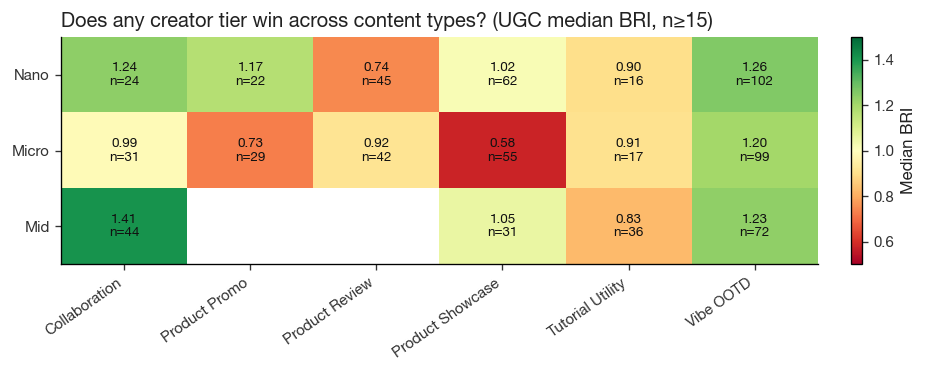

In [4]:
tier_bri = pd.read_csv(DATA / "ugc_tier_content_bri.csv", index_col="scale")
tier_n = pd.read_csv(DATA / "ugc_tier_content_n.csv", index_col="scale")
show(scale_content_bri_heatmap(
    tier_bri,
    title="Does any creator tier win across content types? (UGC median BRI, n≥15)",
    n_counts=tier_n,
))

**Takeaway:** Vibe / OOTD is above baseline in every UGC tier (1.20–1.26), but for other content types the strongest tier shifts — Collaboration peaks with mid-tier creators (1.41) while Product Showcase dips with micro creators (0.58) — so no single tier wins across the board.

<small>**Scope:** UGC videos with a content-type label; official accounts are excluded because they are concentrated in the macro / mega follower tiers. Blank cells have fewer than 15 videos; macro and mega tiers have no cell that reaches 15. Tiers: nano < 10k, micro 10k–100k, mid 100k–1M followers.</small>

### Collaboration signal
Collaboration language appears in only **146 videos (3.3%)**, but those videos show median BRI **1.13 vs 1.00** and median WER **0.74% vs 0.64%**, with lower median views (~83k vs ~115k). This is association, not verified sponsorship impact.

### The decision
**Optimize creator–content fit, not follower count alone.**

---
# 4 · READ THE RESPONSE
## Overall sentiment is less useful than knowing where perception strengthens or breaks down

### Business question
**What do people react positively to — and where does friction appear?**

This section uses comments from **105 high-engagement videos (10,406 comments, 8,716 sentiment-scored)** — a diagnostic subsample, **not** a full Nike / Adidas audience survey. It reads the comments in three steps: **overall → where (which videos) → what (which topics)**.

**Overall:** Adidas comments are warmer — **42.6%** positive / 16.2% negative vs **36.8%** / 17.6% for Nike.

**Where is that warmth concentrated?** Group each comment by the content type of the video it sits under:

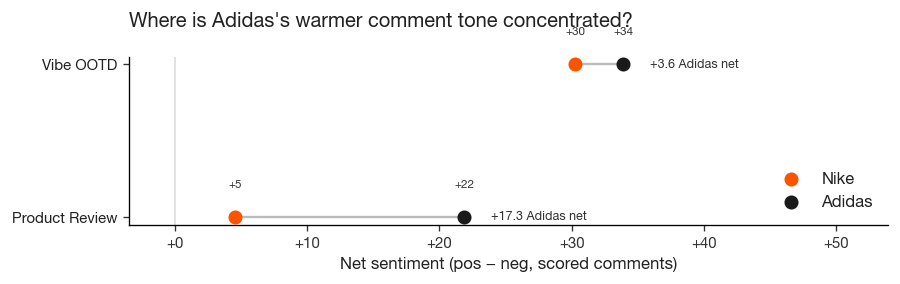

In [5]:
content_sentiment = pd.read_csv(DATA / "content_type_sentiment.csv")
both_brands = content_sentiment.groupby("level")["brand"].transform("nunique") == 2
fig = content_type_sentiment_dumbbell(
    content_sentiment[both_brands],
    metric="net",
    title="Where is Adidas's warmer comment tone concentrated?",
    min_count=30,
)
ax = fig.axes[0]
title = ax.get_title(loc="left") or ax.get_title()
ax.set_title("")
ax.set_title(title, loc="left", pad=18)
fig.set_size_inches(fig.get_size_inches()[0], 2.8)
show(fig)

**Takeaway:** The gap sits in Product Review videos — net +21.9 for Adidas vs +4.5 for Nike (28.4% negative) — while on Vibe / OOTD, the reference row, the brands are close (+33.9 vs +30.3). Adidas's Product Review videos draw warm comments even though they sit 38% below Adidas's engagement baseline (Section 1).

<small>**Grouping:** by the **video's** content type, regardless of what each comment says. Scored comments on content-labeled videos; content types with ≥30 scored comments for both brands.<br>
**Product Review** is a content-type classification, not a verified indication that the creator independently reviewed or endorsed the product.</small>

**What are people praising or pushing back on?** Now group each comment by its **own topic**, regardless of the video it sits under:

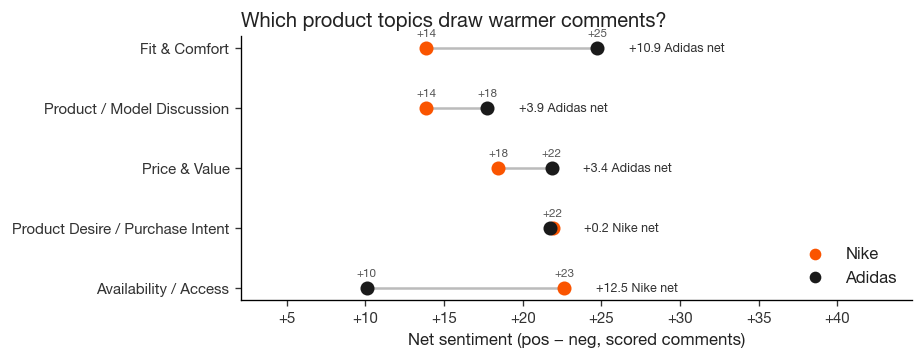

In [6]:
DECISION_TOPICS = [
    "Fit & Comfort",
    "Product / Model Discussion",
    "Price & Value",
    "Product Desire / Purchase Intent",
    "Availability / Access",
]
topics = pd.read_csv(DATA / "topic_sentiment_net.csv")
show(dedupe_labels(topic_sentiment_gap_dumbbell(
    topics[topics["topic"].isin(DECISION_TOPICS)],
    title="Which product topics draw warmer comments?",
    metric="net",
    min_brand_n=25,
)))

**Takeaway:** Adidas leads on product-evaluation topics — Fit & Comfort (net +24.7 vs +13.9) and Product / Model Discussion (+17.8 vs +13.9) — consistent in direction with its warmer Product Review comments. Nike leads on Availability / Access (+22.6 vs +10.1; 19.2% of Adidas comments negative vs 3.8%), and purchase intent is level (+21.7 vs +21.9).

<small>**Grouping:** by each **comment's** topic, across all videos — so this is not a breakdown of Product Review comments, and the two charts are not cross-tabulated. About 29% of comments fall into substantive topics; both brands need ≥25 scored comments in a topic, so Quality / Performance and Brand Comparison are not shown. Athlete / Celebrity and Design & Aesthetics are omitted because the brands are within 1 point (see `04d`).</small>

### The decision
**Use TikTok comments as a diagnostic listening layer — not as one brand-wide sentiment score.** Adidas's warmth comes from product evaluation and its friction from access; Nike's review conversation is the more polarized one.

---
# 5 · PRIORITIZE
## Predicting less, prioritizing better

### Business question
**If a team can review only a fraction of candidate videos, can pre-publish signals make that shortlist richer in top performers?**

- Inputs are known before posting: creator profile, content and caption labels, text and visual (CLIP) embeddings, duration and timing. Post-publish engagement is excluded.
- Predicting exact WER barely beat a brand-median baseline (~3% lower error), so the model is framed as **ranking**, not forecasting.

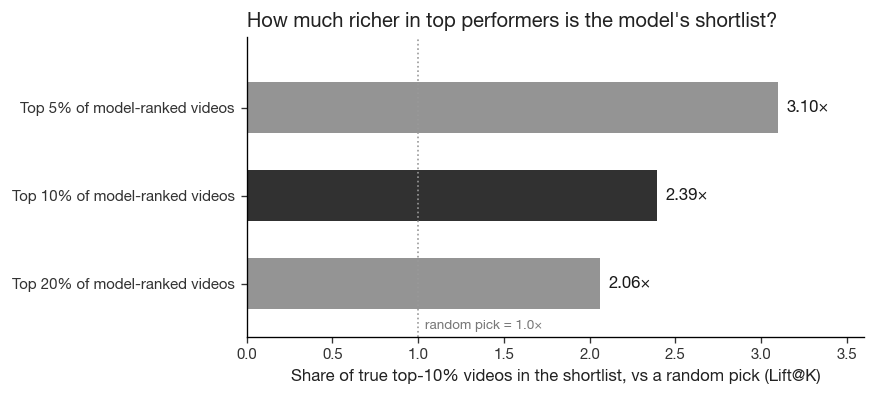

In [7]:
lift = SUMMARY["screening"]
ks = ["Top 5%", "Top 10%", "Top 20%"]
vals = [lift["lift_at_5"], lift["lift_at_10"], lift["lift_at_20"]]
plt.rcParams.update(PLOT_RC)
fig, ax = plt.subplots(figsize=(7.4, 3.4))
y = np.arange(len(ks))[::-1]
ax.barh(y, vals, height=0.58, color=[MUTED, INK, MUTED], alpha=0.9)
ax.axvline(1.0, color="#999", ls=":", lw=1)
ax.text(1.04, -0.48, "random pick = 1.0×", ha="left", va="center", fontsize=8, color="#777")
for yi, v in zip(y, vals):
    ax.text(v + 0.05, yi, f"{v:.2f}×", va="center", fontsize=10, fontweight="bold", color=INK)
ax.set_yticks(y)
ax.set_yticklabels([f"{k} of model-ranked videos" for k in ks])
ax.set_xlim(0, 3.6)
ax.set_ylim(-0.6, 2.8)
ax.set_xlabel("Share of true top-10% videos in the shortlist, vs a random pick (Lift@K)")
ax.set_title("How much richer in top performers is the model's shortlist?", loc="left")
fig.tight_layout()
show(fig)

**Takeaway:** The model's top 10% contains 24.1% true top-decile videos versus ~10% for a random pick (2.39×), and the most selective top 5% reaches 3.10× — the signal concentrates at the top of the ranking.

<small>**Scope:** 4,418 videos from 2,614 creators (videos missing engagement data or a visual embedding are excluded); out-of-fold scores from 5-fold cross-validation grouped by creator, so every score is for creators the model never saw. Results from `03`; no ROC, SHAP or regression diagnostics are repeated here.<br>
**“Top 10%”** means top 10% by WER (not BRI); in the model the cut-off is set within each training fold.</small>

### The decision
**Use the score to order a review queue, then apply human and strategic judgment.** It is not a prediction that any single video will perform.

---
# 6 · FROM INSIGHT TO ACTION
## What should each brand investigate next?

### Adidas
**Protect / reinforce**
- Vibe / OOTD (+21%) and Collaboration (+12%) are established relative strengths.
- Fit & Comfort conversation is comparatively warm (net +24.7 vs +13.9).

**Investigate**
- Availability / Access friction: 19.2% of Adidas comments on the topic are negative (Nike 3.8%).
- Product Review: comments are warm (net +21.9) but the videos sit 38% below the Adidas baseline. Is the format limiting the reach of well-received reviews?

**Test**
- Creator-led lifestyle executions that keep the platform-native feel while selectively introducing product cues.

### Nike
**Protect / reinforce**
- Collaboration (+13%) and Tutorial / Utility (+11%) are stronger relative territories.
- Technical / performance positioning remains distinctive.

**Investigate**
- Product Promo is Nike's second-largest labeled content type (88 videos) yet sits 8% below the Nike baseline; Official Campaign content sits furthest below (−68%, n=28).
- Product Review conversation is polarized (33.0% positive / 28.4% negative).

**Test**
- Utility-led and collaboration-led creative against Product Promo executions.

### Across both brands
**Do not optimize one variable in isolation.** Each experiment should specify:

**Content territory × Commerce intensity × Creator profile × Audience response hypothesis**

and the screening model can order candidates within each test cell before human review.

---
# 7 · WHAT NOT TO CLAIM

This report intentionally avoids several tempting but unsupported conclusions:

- ❌ “Adidas is better than Nike on TikTok.”
- ❌ “Commerce reduces engagement.”
- ❌ “Micro creators outperform macro creators.”
- ❌ “Collaboration causes higher engagement.”
- ❌ “Positive sentiment means purchase intent.”
- ❌ “Product Review videos are independent reviews or endorsements.”
- ❌ “The model predicts which video will go viral.”
- ❌ “These findings represent all TikTok users.”

Use: **“in this sample”**, **“associated with”**, **“above / below brand baseline”**, **“worth testing”**, **“diagnostic signal”**.

---
# Appendix · Where the evidence lives

| Detailed evidence | Source |
|---|---|
| EDA, distributions, label coverage | `01_eda.ipynb` |
| Content strategy & within-brand relative performance | `02_descriptive_crosstabs.ipynb` |
| Predictive screening (Lift@K, CV design, SHAP) | `03_engagement_modeling.ipynb` |
| Awareness write-up | `04a_theme_awareness.ipynb` |
| Commerce intensity & matrices | `04b_theme_commerce.ipynb` |
| Creator tiers & collaboration | `04c_theme_influencer.ipynb` |
| Comment sentiment & topics | `04d_theme_sentiment.ipynb` |
| Charts in this report | `executive_data/` (grouped aggregates only), built by `scripts/build_executive_data.py` |